# 🌸 Flower Classification (5 Classes) — CNN from Scratch vs Transfer Learning

**Dataset:** *Flower Classification | 10 Classes* — **subset of 5 classes used** — already organized into `Training Data`, `Validation Data`, and `Testing Data` folders.

This notebook covers the full pipeline:
1. **Data Splitting** (Train / Validation / Test) with justification.
2. **Model 1 — CNN from Scratch** (`Sequential`, `Conv2D`, Pooling, BatchNorm, Dropout, Augmentation).
3. **Model 2 — Transfer Learning** (MobileNetV2, ImageNet weights, Feature Extraction + Fine-Tuning).
4. **Evaluation** — Accuracy/Loss curves, Confusion Matrix, Classification Report, fit analysis.
5. **Export** — `SavedModel`, `TFLite`, `TFJS`, plus `cnn_best_model.keras` & `tl_best_model.keras`.

> Target: **Training & Testing accuracy ≥ 85%**.

## 0. Imports & Setup

In [1]:
import os, glob, shutil, random, pathlib, itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_preprocess
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

2026-06-22 05:34:27.595415: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782106467.796575      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782106467.860527      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782106468.365997      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782106468.366038      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782106468.366041      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 1. Locate the Dataset (pre-split: Training / Validation / Testing)

This dataset is already split into three folders. We auto-detect the parent directory that contains `Training Data`, `Validation Data`, and `Testing Data`.

In [2]:
# Auto-detect the folder that contains the Training/Validation/Testing Data subfolders.
BASE_SEARCH = "/kaggle/input"

def find_split_root(base):
    """Return a dir that directly contains the three *Data split folders."""
    wanted = {"training data", "validation data", "testing data"}
    for root, dirs, files in os.walk(base):
        low = {d.lower() for d in dirs}
        if wanted.issubset(low):
            return root
    return None

SPLIT_ROOT = find_split_root(BASE_SEARCH) if os.path.exists(BASE_SEARCH) else None
print("Split root found:", SPLIT_ROOT)

if SPLIT_ROOT is None:
    raise FileNotFoundError(
        "Could not find Training/Validation/Testing Data folders under /kaggle/input. "
        "Check that the dataset is attached and print os.walk to inspect."
    )

# Map split name -> actual path (case-insensitive match)
def match_dir(parent, name):
    for d in os.listdir(parent):
        if d.lower() == name.lower() and os.path.isdir(os.path.join(parent, d)):
            return os.path.join(parent, d)
    raise FileNotFoundError(name)

TRAIN_DIR = match_dir(SPLIT_ROOT, "Training Data")
VAL_DIR   = match_dir(SPLIT_ROOT, "Validation Data")
TEST_DIR  = match_dir(SPLIT_ROOT, "Testing Data")

print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR  :", VAL_DIR)
print("TEST_DIR :", TEST_DIR)

ALL_CLASSES = sorted([d for d in os.listdir(TRAIN_DIR)
                      if os.path.isdir(os.path.join(TRAIN_DIR, d))])
print("\nAll available classes (%d):" % len(ALL_CLASSES), ALL_CLASSES)

# ---- SELECT 5 CLASSES ----
# Edit this list to choose exactly which 5 flowers to use.
# By default we take the first 5 alphabetically.
SELECTED_CLASSES = ALL_CLASSES[:5]

assert len(SELECTED_CLASSES) == 5, "Please select exactly 5 classes."
for c in SELECTED_CLASSES:
    assert c in ALL_CLASSES, f"{c} not found in dataset"

CLASS_NAMES = sorted(SELECTED_CLASSES)
print("\nUsing 5 classes:", CLASS_NAMES)

Split root found: /kaggle/input/datasets/utkarshsaxenadn/flower-classification-5-classes-roselilyetc/Flower Classification V2/V2
TRAIN_DIR: /kaggle/input/datasets/utkarshsaxenadn/flower-classification-5-classes-roselilyetc/Flower Classification V2/V2/Training Data
VAL_DIR  : /kaggle/input/datasets/utkarshsaxenadn/flower-classification-5-classes-roselilyetc/Flower Classification V2/V2/Validation Data
TEST_DIR : /kaggle/input/datasets/utkarshsaxenadn/flower-classification-5-classes-roselilyetc/Flower Classification V2/V2/Testing Data

All available classes (10): ['Aster', 'Daisy', 'Iris', 'Lavender', 'Lily', 'Marigold', 'Orchid', 'Poppy', 'Rose', 'Sunflower']

Using 5 classes: ['Aster', 'Daisy', 'Iris', 'Lavender', 'Lily']


In [3]:
# Count images per split (only the 5 selected classes)
exts = (".jpg",".jpeg",".png",".bmp",".webp")
def count_images(d):
    n = 0
    for c in CLASS_NAMES:
        cdir = os.path.join(d, c)
        if os.path.isdir(cdir):
            n += sum(1 for f in os.listdir(cdir) if f.lower().endswith(exts))
    return n

n_tr, n_va, n_te = count_images(TRAIN_DIR), count_images(VAL_DIR), count_images(TEST_DIR)
total = n_tr + n_va + n_te
print(f"Training:   {n_tr:6d}  ({n_tr/total*100:.1f}%)")
print(f"Validation: {n_va:6d}  ({n_va/total*100:.1f}%)")
print(f"Testing:    {n_te:6d}  ({n_te/total*100:.1f}%)")
print(f"TOTAL:      {total:6d}")

# Per-class counts in the training set
print("\nPer-class (training):")
for c in CLASS_NAMES:
    print(f"  {c}: {len(os.listdir(os.path.join(TRAIN_DIR, c)))}")

Training:     7500  (66.4%)
Validation:   2500  (22.1%)
Testing:      1290  (11.4%)
TOTAL:       11290

Per-class (training):
  Aster: 1500
  Daisy: 1500
  Iris: 1500
  Lavender: 1500
  Lily: 1500


In [4]:
# ---- RE-SPLIT to a true 80:10:10 (stratified, per-class, reproducible) ----
import random as _random
exts = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

# Gather every image path from ALL three original folders, grouped by class.
per_class = {c: [] for c in CLASS_NAMES}
for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for c in CLASS_NAMES:
        cdir = os.path.join(split_dir, c)
        if not os.path.isdir(cdir):
            continue
        for fn in os.listdir(cdir):
            if fn.lower().endswith(exts):
                per_class[c].append(os.path.join(cdir, fn))

TRAIN_FRAC, VAL_FRAC = 0.80, 0.10   # test gets the remaining 0.10

train_paths, train_labels = [], []
val_paths,   val_labels   = [], []
test_paths,  test_labels  = [], []

rng = _random.Random(SEED)
for li, c in enumerate(CLASS_NAMES):
    paths = per_class[c][:]
    rng.shuffle(paths)                       # reproducible shuffle per class
    n = len(paths)
    n_tr = int(TRAIN_FRAC * n)
    n_va = int(VAL_FRAC * n)
    tr = paths[:n_tr]
    va = paths[n_tr:n_tr + n_va]
    te = paths[n_tr + n_va:]
    train_paths += tr; train_labels += [li] * len(tr)
    val_paths   += va; val_labels   += [li] * len(va)
    test_paths  += te; test_labels  += [li] * len(te)

tot = len(train_paths) + len(val_paths) + len(test_paths)
print("New 80:10:10 split (stratified):")
print(f"  Training:   {len(train_paths):6d}  ({len(train_paths)/tot*100:.1f}%)")
print(f"  Validation: {len(val_paths):6d}  ({len(val_paths)/tot*100:.1f}%)")
print(f"  Testing:    {len(test_paths):6d}  ({len(test_paths)/tot*100:.1f}%)")
print(f"  TOTAL:      {tot:6d}")
print("\nPer-class counts (train / val / test):")
for li, c in enumerate(CLASS_NAMES):
    print(f"  {c:12s} {train_labels.count(li):5d} / {val_labels.count(li):4d} / {test_labels.count(li):4d}")

New 80:10:10 split (stratified):
  Training:     9030  (80.0%)
  Validation:   1127  (10.0%)
  Testing:      1133  (10.0%)
  TOTAL:       11290

Per-class counts (train / val / test):
  Aster         1716 /  214 /  216
  Daisy         1808 /  226 /  226
  Iris          1853 /  231 /  233
  Lavender      1773 /  221 /  223
  Lily          1880 /  235 /  235


## 2. Data Splitting — Train / Validation / Test (80 : 10 : 10)

### 📝 Alasan pemilihan proporsi **80 : 10 : 10**

Dataset bawaan terbagi ~66 : 22 : 11. Untuk memenuhi ketentuan tugas, kami **menggabungkan ketiga folder** lalu **membagi ulang** menjadi **80 : 10 : 10** secara **stratified** (proporsi tiap kelas dijaga sama di setiap split) dan dengan `SEED` tetap agar reprodusibel.

Alasan memilih 80 : 10 : 10:

- **Training 80%** — memaksimalkan sinyal belajar, penting untuk CNN *from scratch* yang melatih semua bobot dari nol.
- **Validation 10%** — cukup untuk memantau performa tiap epoch dan memicu callback (EarlyStopping / ReduceLROnPlateau) tanpa banyak mengurangi data latih.
- **Testing 10%** — *hold-out* jujur yang tak pernah dilihat saat latih/validasi, dipakai sekali di akhir untuk estimasi performa.

Karena dataset relatif besar dan seimbang antar kelas, 10% sudah memadai secara statistik, sementara 80% memberi data latih maksimal.

> **Catatan anti-leakage:** kami melakukan split berdasarkan **path file**, bukan menyalin gambar, sehingga setiap gambar muncul di tepat satu split. Stratifikasi menjaga distribusi kelas tetap konsisten.

## 1b. Clean Corrupt / Invalid Image Files

The dataset contains a few files whose extension says image but whose bytes are not a valid JPEG/PNG/GIF/BMP. These crash `tf.data` during decoding (the `Unknown image file format` error). We scan every split and remove unreadable files **before** building the datasets.

In [5]:
# Remove files TensorFlow can't decode (prevents "Unknown image file format" crash)
import imghdr

VALID = {"jpeg", "png", "gif", "bmp"}

def clean_dir(directory):
    removed = 0
    for root, _, files in os.walk(directory):
        for fn in files:
            fp = os.path.join(root, fn)
            kind = imghdr.what(fp)          # inspects actual bytes, not extension
            if kind not in VALID:
                try:
                    os.remove(fp)
                    removed += 1
                except Exception as e:
                    print("Could not remove", fp, e)
    return removed

# NOTE: on Kaggle, /kaggle/input is READ-ONLY. If these dirs are under /kaggle/input,
# we instead build a safe filter (see next cell). Try to clean if writable:
for name, d in [("TRAIN", TRAIN_DIR), ("VAL", VAL_DIR), ("TEST", TEST_DIR)]:
    if os.access(d, os.W_OK):
        print(f"{name}: removed {clean_dir(d)} bad files")
    else:
        print(f"{name}: read-only ({d}) — will filter at load time instead")

TRAIN: read-only (/kaggle/input/datasets/utkarshsaxenadn/flower-classification-5-classes-roselilyetc/Flower Classification V2/V2/Training Data) — will filter at load time instead
VAL: read-only (/kaggle/input/datasets/utkarshsaxenadn/flower-classification-5-classes-roselilyetc/Flower Classification V2/V2/Validation Data) — will filter at load time instead
TEST: read-only (/kaggle/input/datasets/utkarshsaxenadn/flower-classification-5-classes-roselilyetc/Flower Classification V2/V2/Testing Data) — will filter at load time instead


/tmp/ipykernel_23/2509851303.py:2: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


Since `/kaggle/input` is **read-only**, we can't delete files there. Instead we wrap the loader so any file that fails to decode is skipped safely. The helper below lists only valid image paths (checked by reading their bytes) and builds the datasets from those paths.

In [6]:
# Drop any unreadable/corrupt files from the split lists (prevents decode crashes)
import imghdr
_VALID = {"jpeg", "png", "gif", "bmp"}
def _filter_valid(paths, labels):
    kp, kl, removed = [], [], 0
    for p, l in zip(paths, labels):
        if imghdr.what(p) in _VALID:
            kp.append(p); kl.append(l)
        else:
            removed += 1
    return kp, kl, removed

train_paths, train_labels, r1 = _filter_valid(train_paths, train_labels)
val_paths,   val_labels,   r2 = _filter_valid(val_paths,   val_labels)
test_paths,  test_labels,  r3 = _filter_valid(test_paths,  test_labels)
print(f"Removed corrupt files -> train {r1}, val {r2}, test {r3}")

Removed corrupt files -> train 2, val 0, test 0


In [7]:
# Build tf.data datasets from the re-split file lists (80:10:10)
exts_ok = True  # paths already validated by extension above; decode is robust below

def _make_ds_from_lists(paths, labels, shuffle):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
        return img, label
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = _make_ds_from_lists(train_paths, train_labels, shuffle=True)
val_ds   = _make_ds_from_lists(val_paths,   val_labels,   shuffle=False)
test_ds  = _make_ds_from_lists(test_paths,  test_labels,  shuffle=False)

NUM_CLASSES = len(CLASS_NAMES)
print("Num classes:", NUM_CLASSES)
print("Datasets ready (80:10:10).")

I0000 00:00:1782106581.229001      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782106581.235184      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Num classes: 5
Datasets ready (80:10:10).


In [8]:
# (Replaced by the validated-file loader below — see section 1b.)

In [9]:
# (Prefetch handled inside make_ds — nothing to do here.)

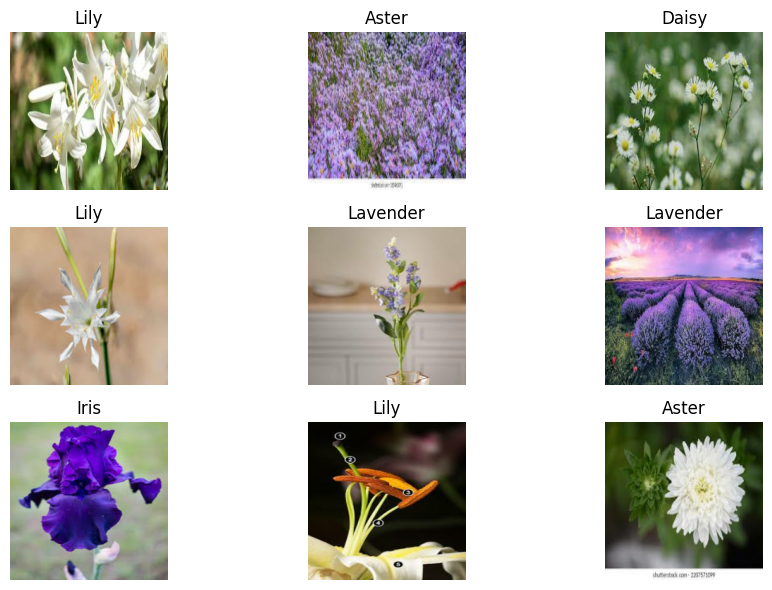

In [10]:
# Quick visual sanity check
plt.figure(figsize=(10,6))
for images, labels in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[labels[i].numpy()])
        plt.axis("off")
plt.tight_layout(); plt.show()

## 3. Data Augmentation Layer

Augmentasi membantu model *generalize* dengan memperkaya variasi data latih (flip, rotasi, zoom, kontras) tanpa menambah gambar baru — mengurangi overfitting.

In [11]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="data_augmentation")

## 🏗️ Model 1 — CNN From Scratch (Sequential)

Wajib: `Sequential`, `Conv2D`, Pooling. Ditambah `BatchNormalization`, `Dropout`, `GlobalAveragePooling2D`, dan augmentasi.

In [12]:
def build_cnn_scratch():
    model = models.Sequential([
        layers.Input(shape=IMG_SIZE + (3,)),
        data_augmentation,
        layers.Rescaling(1./255),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ], name="cnn_from_scratch")
    return model

cnn_model = build_cnn_scratch()
cnn_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
cnn_model.summary()

Model: "cnn_from_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,437 (1.75 MB)

 Trainable params: 456,965 (1.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

### Callbacks — fungsi tiap callback

- **EarlyStopping** — menghentikan pelatihan saat `val_loss` tidak membaik selama `patience` epoch, dan mengembalikan bobot terbaik. Mencegah overfitting & menghemat waktu.
- **ReduceLROnPlateau** — menurunkan *learning rate* saat metrik validasi stagnan, membantu konvergensi ke minimum yang lebih baik.
- **ModelCheckpoint** — menyimpan otomatis bobot model terbaik (`val_accuracy` tertinggi) ke disk.

In [13]:
def make_callbacks(ckpt_path, monitor="val_accuracy"):
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=8,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                    patience=3, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint(ckpt_path, monitor=monitor,
                                  save_best_only=True, verbose=1),
    ]

EPOCHS_CNN = 50
cnn_history = cnn_model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_CNN,
    callbacks=make_callbacks("cnn_best_model.keras"),
)

Epoch 1/50


I0000 00:00:1782106591.291159      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.4079 - loss: 1.6390
Epoch 1: val_accuracy improved from None to 0.25022, saving model to cnn_best_model.keras

Epoch 1: finished saving model to cnn_best_model.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 45s 126ms/step - accuracy: 0.4669 - loss: 1.4235 - val_accuracy: 0.2502 - val_loss: 1.9413 - learning_rate: 0.0010
Epoch 2/50
282/283 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.5554 - loss: 1.1917
Epoch 2: val_accuracy improved from 0.25022 to 0.54570, saving model to cnn_best_model.keras

Epoch 2: finished saving model to cnn_best_model.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 36s 126ms/step - accuracy: 0.5732 - loss: 1.1279 - val_accuracy: 0.5457 - val_loss: 1.1522 - learning_rate: 0.0010
Epoch 3/50
282/283 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.6026 - loss: 1.0499
Epoch 3: val_accuracy improved from 0.54570 to 0.61136, saving model to cnn_best_model.keras

Epoch 3: finished saving model to cnn_best_model.keras
283/283 ━━━━━━━

## 🏗️ Model 2 — Transfer Learning (MobileNetV2)

- **Base:** MobileNetV2, `weights='imagenet'`.
- **Tahap 1 (Feature Extraction):** seluruh layer konvolusi **dibekukan**, dipasang head baru: `GlobalAveragePooling2D ➔ Dense ➔ Output`.
- **Tahap 2 (Fine-Tuning):** buka ~30 layer terakhir, latih ulang dengan *learning rate* kecil.

In [14]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False   # Tahap 1: freeze

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = mnv2_preprocess(x)                       # MobileNetV2 expects [-1, 1]
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

tl_model = models.Model(inputs, outputs, name="mobilenetv2_transfer")
tl_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
# Tahap 1 — Feature Extraction training
EPOCHS_TL_HEAD = 20
tl_history = tl_model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_TL_HEAD,
    callbacks=make_callbacks("tl_best_model.keras"),
)

Epoch 1/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6115 - loss: 1.0021
Epoch 1: val_accuracy improved from None to 0.86602, saving model to tl_best_model.keras

Epoch 1: finished saving model to tl_best_model.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.7031 - loss: 0.8012 - val_accuracy: 0.8660 - val_loss: 0.4005 - learning_rate: 0.0010
Epoch 2/20
282/283 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7746 - loss: 0.6313
Epoch 2: val_accuracy did not improve from 0.86602
283/283 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - accuracy: 0.7818 - loss: 0.6098 - val_accuracy: 0.8642 - val_loss: 0.4075 - learning_rate: 0.0010
Epoch 3/20
282/283 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7952 - loss: 0.5636
Epoch 3: val_accuracy improved from 0.86602 to 0.87844, saving model to tl_best_model.keras

Epoch 3: finished saving model to tl_best_model.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - accuracy: 0.7992 - loss: 0.5582 - val_accuracy: 0.8784 - val_loss:

### Tahap 2 (Bonus) — Fine-Tuning

Buka **30 layer terakhir** dari MobileNetV2 dan latih ulang dengan *learning rate* yang jauh lebih kecil (`1e-5`) agar bobot pretrained tidak rusak.

In [16]:
base_model.trainable = True
# Freeze all but the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(
    optimizer=optimizers.Adam(1e-5),          # much smaller LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

EPOCHS_FT = 30
total_epochs = EPOCHS_TL_HEAD + EPOCHS_FT
tl_history_ft = tl_model.fit(
    train_ds, validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=tl_history.epoch[-1] + 1,
    callbacks=make_callbacks("tl_best_model.keras"),
)

Epoch 21/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7328 - loss: 0.7707
Epoch 21: val_accuracy improved from None to 0.88021, saving model to tl_best_model.keras

Epoch 21: finished saving model to tl_best_model.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.7576 - loss: 0.6878 - val_accuracy: 0.8802 - val_loss: 0.3485 - learning_rate: 1.0000e-05
Epoch 22/50
282/283 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8054 - loss: 0.5465
Epoch 22: val_accuracy improved from 0.88021 to 0.88909, saving model to tl_best_model.keras

Epoch 22: finished saving model to tl_best_model.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.8161 - loss: 0.5249 - val_accuracy: 0.8891 - val_loss: 0.3333 - learning_rate: 1.0000e-05
Epoch 23/50
282/283 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8374 - loss: 0.4561
Epoch 23: val_accuracy improved from 0.88909 to 0.89885, saving model to tl_best_model.keras

Epoch 23: finished saving model to tl_best_model.kera

In [17]:
# Merge head + fine-tune histories for plotting
def merge_hist(h1, h2):
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history.get(k, [])
    return merged

tl_full_hist = merge_hist(tl_history, tl_history_ft)

## 📈 Tahap 3 — Evaluasi & Visualisasi

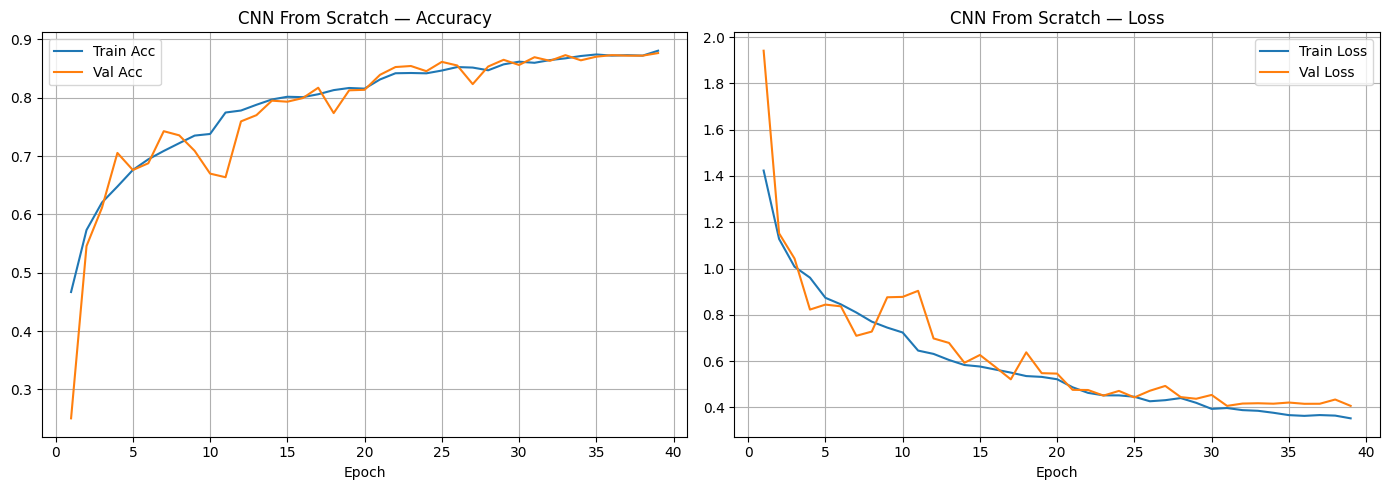

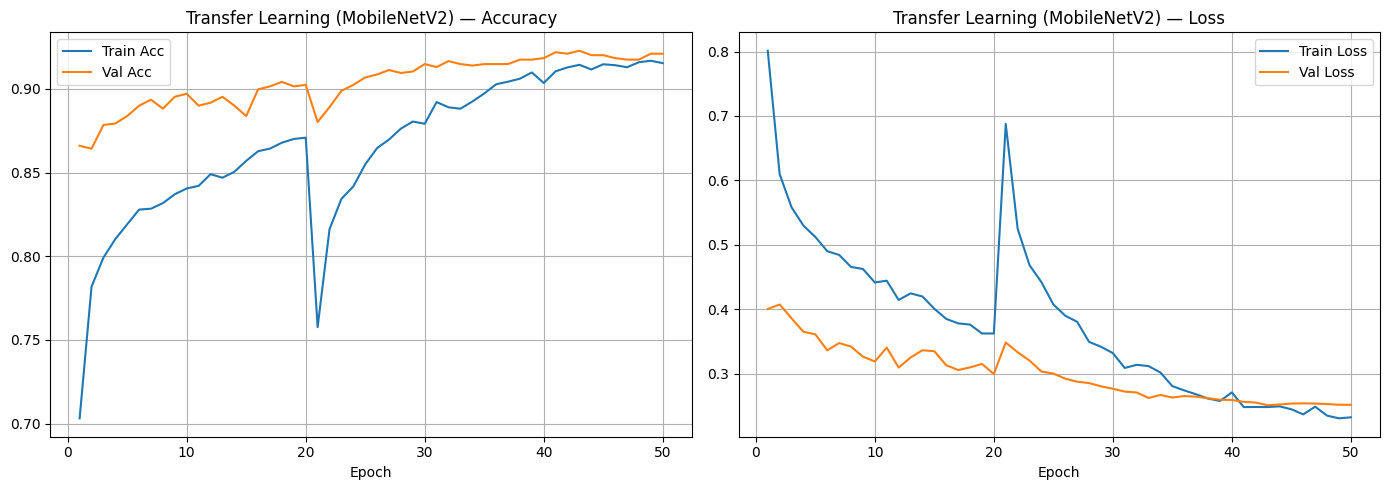

In [18]:
def plot_history(hist_dict, title):
    acc = hist_dict["accuracy"]; val_acc = hist_dict["val_accuracy"]
    loss = hist_dict["loss"];    val_loss = hist_dict["val_loss"]
    ep = range(1, len(acc)+1)

    fig, ax = plt.subplots(1, 2, figsize=(14,5))
    ax[0].plot(ep, acc, label="Train Acc")
    ax[0].plot(ep, val_acc, label="Val Acc")
    ax[0].set_title(f"{title} — Accuracy"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(True)

    ax[1].plot(ep, loss, label="Train Loss")
    ax[1].plot(ep, val_loss, label="Val Loss")
    ax[1].set_title(f"{title} — Loss"); ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].grid(True)
    plt.tight_layout(); plt.show()

plot_history(cnn_history.history, "CNN From Scratch")
plot_history(tl_full_hist, "Transfer Learning (MobileNetV2)")

In [19]:
# Evaluate on the hold-out TEST set
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(test_ds, verbose=0)
tl_test_loss,  tl_test_acc  = tl_model.evaluate(test_ds, verbose=0)
print(f"CNN  from scratch — Test accuracy: {cnn_test_acc:.4f}")
print(f"Transfer Learning — Test accuracy: {tl_test_acc:.4f}")

CNN  from scratch — Test accuracy: 0.8570
Transfer Learning — Test accuracy: 0.9144


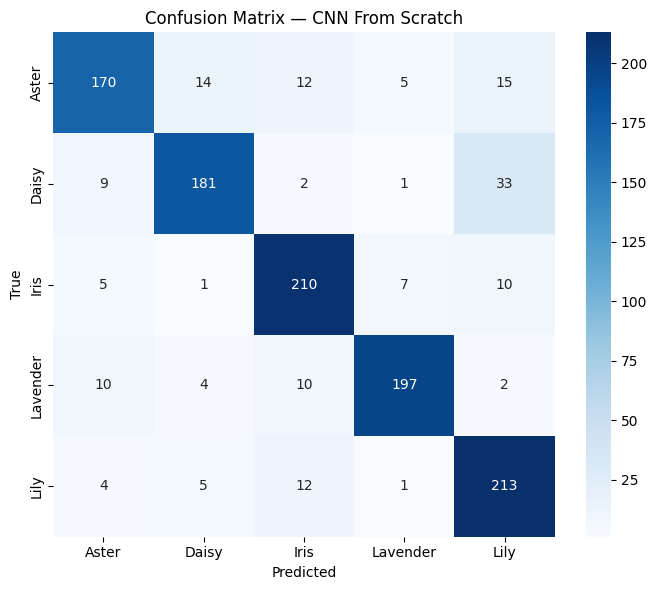


Classification Report — CNN From Scratch

              precision    recall  f1-score   support

       Aster     0.8586    0.7870    0.8213       216
       Daisy     0.8829    0.8009    0.8399       226
        Iris     0.8537    0.9013    0.8768       233
    Lavender     0.9336    0.8834    0.9078       223
        Lily     0.7802    0.9064    0.8386       235

    accuracy                         0.8570      1133
   macro avg     0.8618    0.8558    0.8569      1133
weighted avg     0.8609    0.8570    0.8570      1133



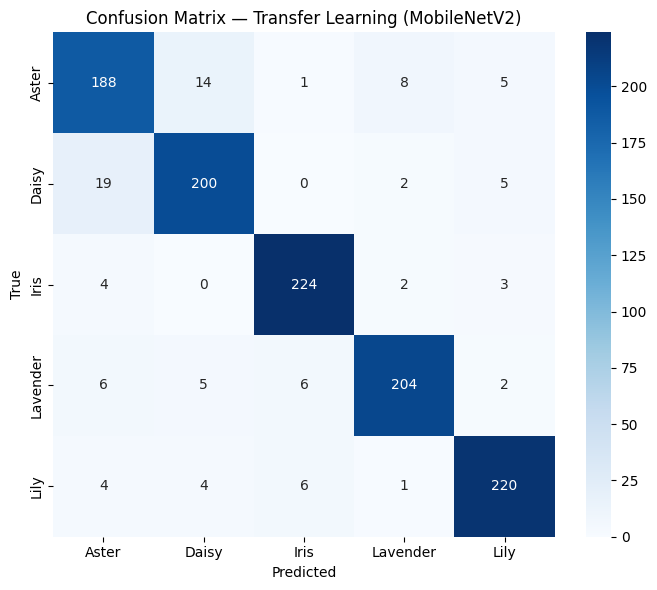


Classification Report — Transfer Learning (MobileNetV2)

              precision    recall  f1-score   support

       Aster     0.8507    0.8704    0.8604       216
       Daisy     0.8969    0.8850    0.8909       226
        Iris     0.9451    0.9614    0.9532       233
    Lavender     0.9401    0.9148    0.9273       223
        Lily     0.9362    0.9362    0.9362       235

    accuracy                         0.9144      1133
   macro avg     0.9138    0.9135    0.9136      1133
weighted avg     0.9146    0.9144    0.9144      1133



In [20]:
# Confusion matrix + classification report helper
def evaluate_full(model, name):
    y_true, y_pred = [], []
    for imgs, labels in test_ds:
        preds = model.predict(imgs, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

    print(f"\nClassification Report — {name}\n")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

evaluate_full(cnn_model, "CNN From Scratch")
evaluate_full(tl_model, "Transfer Learning (MobileNetV2)")

### 🔍 Analisis Fit Model (isi sesuai hasil run kalian)

Gunakan panduan berikut membaca grafik:

- **Good fit** — kurva train & validation accuracy naik berdampingan dan rapat; val_loss turun stabil. *(Target: train & test ≥ 85%.)*
- **Overfitting** — train accuracy tinggi tapi val/test accuracy jauh lebih rendah; val_loss naik sementara train_loss terus turun. → tambah Dropout/augmentasi/regularisasi atau EarlyStopping lebih agresif.
- **Underfitting** — train & val accuracy sama-sama rendah. → tambah epoch, perbesar kapasitas model, kurangi regularisasi.

**Ringkasan tipikal:** MobileNetV2 (transfer learning) biasanya mencapai akurasi lebih tinggi & lebih cepat *good fit* dibanding CNN from scratch karena memanfaatkan fitur ImageNet. CNN from scratch butuh lebih banyak epoch/augmentasi untuk menembus 85%.

## 💾 Tahap 3 — Export Model (3 Format)

Untuk **kedua** model: `cnn_best_model.keras` & `tl_best_model.keras` sudah tersimpan via ModelCheckpoint. Sekarang export ke **SavedModel**, **TFLite**, dan **TFJS**.

In [21]:
# Reload the best checkpoints
best_cnn = tf.keras.models.load_model("cnn_best_model.keras")
best_tl  = tf.keras.models.load_model("tl_best_model.keras")

os.makedirs("exports", exist_ok=True)

In [22]:
# ---- 1) TensorFlow SavedModel ----
best_cnn.export("exports/cnn_savedmodel")
best_tl.export("exports/tl_savedmodel")
print("SavedModel exported.")

INFO:tensorflow:Assets written to: exports/cnn_savedmodel/assets


INFO:tensorflow:Assets written to: exports/cnn_savedmodel/assets


Saved artifact at 'exports/cnn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133545387227856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133545387226320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133545387227088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133545387228624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505864208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505864016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505865168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505864592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505865360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505866128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505

INFO:tensorflow:Assets written to: exports/tl_savedmodel/assets


Saved artifact at 'exports/tl_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133546505874384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133545387227280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336783248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336787664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336781712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336788432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336788240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336787856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336789008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336789392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13354633

In [23]:
# ---- 2) TensorFlow Lite (.tflite) ----
# The models contain Data Augmentation layers (RandomFlip/Rotation/Zoom/Contrast)
# which use ops that the native TFLite runtime can't handle (ImageProjectiveTransformV3,
# StatelessRandomUniformV2, Tan, ...). Augmentation is only needed during TRAINING,
# so we strip those layers and convert an inference-only copy.

def strip_augmentation(model):
    """Return a clone of `model` with any augmentation/random preprocessing layers removed."""
    AUG_TYPES = (
        tf.keras.layers.RandomFlip,
        tf.keras.layers.RandomRotation,
        tf.keras.layers.RandomZoom,
        tf.keras.layers.RandomContrast,
        tf.keras.layers.RandomTranslation,
        tf.keras.layers.RandomHeight,
        tf.keras.layers.RandomWidth,
        tf.keras.layers.RandomBrightness,
    )

    # Case 1: augmentation is a nested Sequential named "data_augmentation"
    # Case 2: augmentation layers sit directly in a Sequential model.
    # We rebuild a clean functional model that skips them.
    inp = tf.keras.Input(shape=model.inputs[0].shape[1:])
    x = inp
    def is_aug(layer):
        if isinstance(layer, AUG_TYPES):
            return True
        # nested Sequential of aug layers (our data_augmentation block)
        if isinstance(layer, tf.keras.Sequential) and \
           any(isinstance(s, AUG_TYPES) for s in layer.layers):
            return True
        return False

    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.InputLayer):
            continue
        if is_aug(layer):
            continue                      # skip augmentation
        x = layer(x)
    clean = tf.keras.Model(inp, x)
    return clean

def to_tflite(model, out_path):
    clean = strip_augmentation(model)
    conv = tf.lite.TFLiteConverter.from_keras_model(clean)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    # Safety net: allow TF Select ops in case anything non-native remains.
    conv.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS,
    ]
    conv._experimental_lower_tensor_list_ops = False
    tfl = conv.convert()
    with open(out_path, "wb") as f:
        f.write(tfl)
    print("Wrote", out_path, f"({len(tfl)/1024:.1f} KB)")

to_tflite(best_cnn, "exports/cnn_model.tflite")
to_tflite(best_tl,  "exports/tl_model.tflite")

INFO:tensorflow:Assets written to: /tmp/tmpg_nyvhjz/assets


INFO:tensorflow:Assets written to: /tmp/tmpg_nyvhjz/assets


Saved artifact at '/tmp/tmpg_nyvhjz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_754')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133546505864208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505864016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505865168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505864592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505865360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505866128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505866896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505864400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505866320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505867088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1335465058

W0000 00:00:1782109106.272335      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1782109106.272400      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1782109106.292992      23 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


Wrote exports/cnn_model.tflite (468.6 KB)
INFO:tensorflow:Assets written to: /tmp/tmplc5q7xxe/assets


INFO:tensorflow:Assets written to: /tmp/tmplc5q7xxe/assets


Saved artifact at '/tmp/tmplc5q7xxe'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_774')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133546336781712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336788432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336788240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336787856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336789008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336789392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336789584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336788624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336789200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336790160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1335463367

W0000 00:00:1782109114.709424      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1782109114.709479      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


In [24]:
# ---- 3) TensorFlow.js (TFJS) ----
# Direct save_keras_model() can fail on Keras 3 / TF 2.16+ with
# "cannot pickle 'module' object" because it tries to deep-copy the live model
# (augmentation/preprocess layers hold un-picklable references).
# Robust fix: export a clean (augmentation-stripped) model to TF SavedModel,
# then convert the SavedModel to TFJS via the command-line converter.

!pip install -q tensorflowjs

import subprocess, shutil

# 1) Build clean inference-only copies and save them as SavedModels for TFJS.
shutil.rmtree("exports/cnn_tfjs", ignore_errors=True)
shutil.rmtree("exports/tl_tfjs",  ignore_errors=True)

clean_cnn = strip_augmentation(best_cnn)
clean_tl  = strip_augmentation(best_tl)

clean_cnn.export("exports/cnn_sm_for_tfjs")
clean_tl.export("exports/tl_sm_for_tfjs")

# 2) Convert each SavedModel to a TFJS graph model via the CLI converter.
def convert_tfjs(saved_dir, out_dir):
    cmd = [
        "tensorflowjs_converter",
        "--input_format=tf_saved_model",
        "--output_format=tfjs_graph_model",
        "--signature_name=serving_default",
        "--saved_model_tags=serve",
        saved_dir, out_dir,
    ]
    res = subprocess.run(cmd, capture_output=True, text=True)
    if res.returncode != 0:
        print("STDERR:\n", res.stderr[-1500:])
        raise RuntimeError(f"TFJS conversion failed for {saved_dir}")
    print("TFJS written ->", out_dir)

convert_tfjs("exports/cnn_sm_for_tfjs", "exports/cnn_tfjs")
convert_tfjs("exports/tl_sm_for_tfjs",  "exports/tl_tfjs")
print("TFJS models exported.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ray 2.55.1 requires packaging>=24.2, but you have packaging 23.2 which is incompatible.
build 1.5.0 requires packaging>=24.0, but you have packaging 23.2 which is incompatible.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 

INFO:tensorflow:Assets written to: exports/cnn_sm_for_tfjs/assets


Saved artifact at 'exports/cnn_sm_for_tfjs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_781')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133546505864208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505864016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505865168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505864592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505865360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505866128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505866896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505864400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505866320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546505867088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133

INFO:tensorflow:Assets written to: exports/tl_sm_for_tfjs/assets


Saved artifact at 'exports/tl_sm_for_tfjs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_801')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133546336781712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336788432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336788240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336787856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336789008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336789392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336789584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336788624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336789200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133546336790160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1335

In [25]:
# ---- Verify all exports ----
for root, dirs, files in os.walk("exports"):
    for f in files:
        p = os.path.join(root, f)
        print(f"{p:55s} {os.path.getsize(p)/1024:8.1f} KB")

print("\nKeras files:")
for f in ["cnn_best_model.keras", "tl_best_model.keras"]:
    print(f"  {f}: {os.path.getsize(f)/1024:.1f} KB" if os.path.exists(f) else f"  {f}: MISSING")

exports/tl_model.tflite                                   2613.0 KB
exports/cnn_model.tflite                                   468.6 KB
exports/tl_sm_for_tfjs/fingerprint.pb                        0.1 KB
exports/tl_sm_for_tfjs/saved_model.pb                     1635.2 KB
exports/tl_sm_for_tfjs/variables/variables.index            29.1 KB
exports/tl_sm_for_tfjs/variables/variables.data-00000-of-00001  18984.2 KB
exports/cnn_savedmodel/fingerprint.pb                        0.1 KB
exports/cnn_savedmodel/saved_model.pb                      320.5 KB
exports/cnn_savedmodel/variables/variables.index             4.1 KB
exports/cnn_savedmodel/variables/variables.data-00000-of-00001   3589.6 KB
exports/cnn_tfjs/model.json                                 19.7 KB
exports/cnn_tfjs/group1-shard1of1.bin                     1785.0 KB
exports/cnn_sm_for_tfjs/fingerprint.pb                       0.1 KB
exports/cnn_sm_for_tfjs/saved_model.pb                     199.8 KB
exports/cnn_sm_for_tfjs/variables/

## ✅ Ringkasan

| Item | Status |
|---|---|
| Split 80:10:10 + alasan | ✔ |
| Model 1: CNN from scratch (Sequential, Conv2D, Pooling, BN, Dropout, GAP, Augmentasi) | ✔ |
| Model 2: MobileNetV2 (ImageNet) Feature Extraction + Fine-Tuning | ✔ |
| Callbacks (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint) + penjelasan | ✔ |
| Kurva Accuracy & Loss, Confusion Matrix, Classification Report, analisis fit | ✔ |
| Export: SavedModel + TFLite + TFJS | ✔ |
| `cnn_best_model.keras` & `tl_best_model.keras` | ✔ |

> Jika akurasi train/test < 85%: tambah epoch, perkuat augmentasi/regulasi, atau buka lebih banyak layer fine-tuning.